In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Dataset path
DATASET_PATH = "dataset/liveness"

# Parameters
IMG_SIZE = 128
BATCH_SIZE = 16

print("Dataset folders:")
print(os.listdir(DATASET_PATH))

Dataset folders:
['live', 'spoof']


In [3]:
# Data preprocessing

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

print("Dataset loaded successfully")

Found 15 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Dataset loaded successfully


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Build model
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

C:\Users\Mahdi\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1333 - loss: 0.7531 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step - accuracy: 0.8000 - loss: 0.8670 - val_accuracy: 1.0000 - val_loss: 0.0830
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step - accuracy: 0.8000 - loss: 0.4523 - val_accuracy: 1.0000 - val_loss: 0.3956
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step - accuracy: 0.8667 - loss: 0.4113 - val_accuracy: 1.0000 - val_loss: 0.3334
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step - accuracy: 1.0000 - loss: 0.3630 - val_accuracy: 1.0000 - val_loss: 0.1982
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - accuracy: 0.8667 - loss: 0.2961 - val_accuracy: 1.0000 - val_loss: 0.0932
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step - accuracy: 0.8667 - loss: 0.2636 - val_accuracy: 1.0000 - val_loss: 0.0495
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step - accuracy: 0.9333 - loss: 0.1909 - val_accuracy: 1.0000 - val_loss: 0.

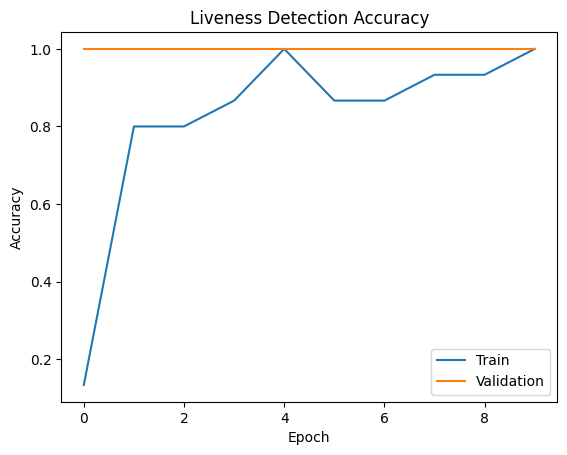

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.legend()

plt.title("Liveness Detection Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

In [9]:
model.save("liveness_model.keras")
print("Liveness model saved")

Liveness model saved


In [10]:
model.save_weights("liveness_model.weights.h5")

In [ ]:
*import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

# Load model
model = load_model("liveness_model.h5")

# Labels
labels = ['Live', 'Spoof']

# Image path
img_path = "test.jpg"

# Read image
img = cv2.imread(img_path)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image
img_resized = cv2.resize(img_rgb, (128, 128))

# Normalize
img_normalized = img_resized / 255.0

# Reshape
img_input = np.expand_dims(img_normalized, axis=0)

# Prediction
prediction = model.predict(img_input)

# Convert prediction
if prediction[0][0] > 0.5:
    result = "Spoof"
else:
    result = "Live"

# Confidence
confidence = prediction[0][0]

# Print result
print("Prediction:", result)

print("Confidence:", confidence)

# Show image
plt.imshow(img_rgb)

plt.title(result)

plt.axis('off')

plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
